In [19]:
from functools import lru_cache
import math

def find_expression(values: list[float], target: float, tol: float = 1e-6):
    if not values:
        return False, 0, ""
    
    values = [float(v) for v in values]
    
    def key(nums):
        return tuple(sorted(round(x, 8) for x in nums))
    
    @lru_cache(maxsize=None)
    def dfs_actions(state_key):
        """Return (solvable, actions) for the multiset represented by state_key."""
        state = list(state_key)
        if len(state) == 1:
            return (abs(state[0] - target) < tol, 0)
        
        n = len(state)
        total_actions = 0
        for i in range(n):
            for j in range(i + 1, n):
                a, b = state[i], state[j]
                rest = [state[k] for k in range(n) if k != i and k != j]
                candidates = [a + b, a * b, a - b, b - a]
                if abs(b) > tol:
                    candidates.append(a / b)
                if abs(a) > tol:
                    candidates.append(b / a)
                for c in candidates:
                    next_key = key(tuple(rest + [c]))
                    solvable, sub_actions = dfs_actions(next_key)
                    total_actions += sub_actions + 1
                    if solvable:
                        return True, total_actions
        return False, total_actions
    
    def dfs_build(vals, exprs):
        """Guided by dfs_actions cache, build one concrete expression if solvable."""
        if len(vals) == 1:
            if abs(vals[0] - target) < tol:
                return True, exprs[0]
            return False, ""
        
        n = len(vals)
        for i in range(n):
            for j in range(i + 1, n):
                a, b = vals[i], vals[j]
                ea, eb = exprs[i], exprs[j]
                rest_vals = [vals[k] for k in range(n) if k != i and k != j]
                rest_exprs = [exprs[k] for k in range(n) if k != i and k != j]
                
                candidates = [
                    (a + b, f"({ea} + {eb})"),
                    (a * b, f"({ea} * {eb})"),
                    (a - b, f"({ea} - {eb})"),
                    (b - a, f"({eb} - {ea})"),
                ]
                if abs(b) > tol:
                    candidates.append((a / b, f"({ea} / {eb})"))
                if abs(a) > tol:
                    candidates.append((b / a, f"({eb} / {ea})"))
                
                for c_val, c_expr in candidates:
                    next_vals = rest_vals + [c_val]
                    if dfs_actions(key(tuple(next_vals)))[0]:
                        ok, sub_expr = dfs_build(next_vals, rest_exprs + [c_expr])
                        if ok:
                            return True, sub_expr
        return False, ""
    
    solvable, actions = dfs_actions(key(tuple(values)))
    if not solvable:
        return False, actions, ""
    ok, expr = dfs_build(values, [str(int(v)) for v in values])
    return ok, actions, expr


In [20]:
import time

nums_list = [
    [56, 70, 23, 71, 53, 56],
    [15, 70, 23, 53, 56],
    [15, 47, 53, 56],
    [15, 47, 53*56],
    [56, 70, 23, 71, 53, 10800]
]
target = 201

for nums in nums_list:
    start_time = time.time()
    solvable, actions, expr = find_expression(nums, target)
    end_time = time.time()
    time_taken = end_time - start_time
    
    print(f"Task: Using numbers {nums} to reach target {target}")
    print(f"Solvable: {solvable}, Actions: {actions}, Expression: {expr}, Time taken: {time_taken:.6f} seconds")


Task: Using numbers [56, 70, 23, 71, 53, 56] to reach target 201
Solvable: True, Actions: 5578954, Expression: ((56 * ((56 - 70) + (71 - 53))) - 23), Time taken: 1.408670 seconds
Task: Using numbers [15, 70, 23, 53, 56] to reach target 201
Solvable: True, Actions: 177783, Expression: (((70 - 23) + (53 * 56)) / 15), Time taken: 0.104913 seconds
Task: Using numbers [15, 47, 53, 56] to reach target 201
Solvable: True, Actions: 4029, Expression: ((47 + (53 * 56)) / 15), Time taken: 0.003704 seconds
Task: Using numbers [15, 47, 2968] to reach target 201
Solvable: True, Actions: 91, Expression: ((47 + 2968) / 15), Time taken: 0.000163 seconds
Task: Using numbers [56, 70, 23, 71, 53, 10800] to reach target 201
Solvable: False, Actions: 24681710, Expression: , Time taken: 5.838853 seconds


In [24]:
find_expression([62, 61, 32, 68, 80*1], 383)

(True, 123018, '((32 * (80 - 68)) - (62 - 61))')

In [4]:
eval("(((53 * 56) - (23 - 70)) / 15)")


201.0

In [5]:
nums   = [23, 56, 71, 53, 70, 56]
target = 201
expr = find_expression(nums, target)
print(expr)
# -> "(((53*56)+(70-23))/(71-56))"   # one valid solution

(True, 10320783)


In [6]:
from datasets import load_dataset

dataset = load_dataset("d1shs0ap/countdown-3-4-5-6-7-8-9")

print(dataset)

/scratch/m000122/stalaei/conda_envs/verl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['target', 'nums'],
        num_rows: 35000
    })
    test: Dataset({
        features: ['target', 'nums'],
        num_rows: 7000
    })
})


In [7]:
# Print a sample from levels 7, 8, and 9
for level in [7, 8, 9]:
    sample = next((entry for entry in dataset['train'] if len(entry['nums']) == level), None)
    if sample:
        print(f"Level {level} Sample: Numbers: {sample['nums']}, Target: {sample['target']}")


Level 7 Sample: Numbers: [76, 10, 72, 1, 11, 44, 5], Target: 844
Level 8 Sample: Numbers: [15, 60, 1, 16, 60, 54, 21, 88], Target: 405
Level 9 Sample: Numbers: [2, 69, 2, 50, 53, 81, 28, 10, 50], Target: 514


In [8]:
samples = [
    {"nums": [76, 10, 72, 1, 11, 44, 5], "target": 844},
    {"nums": [15, 60, 1, 16, 60, 54, 21, 88], "target": 405},
    {"nums": [2, 69, 2, 50, 53, 81, 28, 10, 50], "target": 514}
]

for sample in samples:
    nums = sample["nums"]
    target = sample["target"]
    
    start_time = time.time()
    solvable, actions = find_expression(nums, target)
    end_time = time.time()
    time_taken = end_time - start_time
    
    print(f"Task: Using numbers {nums} to reach target {target}")
    print(f"Solvable: {solvable}, Actions: {actions}, Time taken: {time_taken:.6f} seconds")


Task: Using numbers [76, 10, 72, 1, 11, 44, 5] to reach target 844
Solvable: True, Actions: 670511, Time taken: 0.215240 seconds
Task: Using numbers [15, 60, 1, 16, 60, 54, 21, 88] to reach target 405
Solvable: True, Actions: 3209214, Time taken: 0.369200 seconds
Task: Using numbers [2, 69, 2, 50, 53, 81, 28, 10, 50] to reach target 514
Solvable: True, Actions: 46357833, Time taken: 2.722739 seconds


In [11]:
from tqdm import tqdm
import time
from multiprocessing import Pool, cpu_count
from collections import defaultdict

def process_entry(entry):
    nums, target = entry['nums'], entry['target']
    level = len(nums)
    start_time = time.time()
    solvable, actions = find_expression(nums, target)
    assert solvable, f"Task is not solvable with the given numbers: {nums} -> {target}"
    end_time = time.time()
    time_taken = end_time - start_time
    return level, actions, time_taken

level_action_times = defaultdict(lambda: {"actions": [], "time": []})

def limited_entries(dataset, max_per_level=100):
    level_counts = defaultdict(int)
    for entry in dataset:
        level = len(entry['nums'])
        if level_counts[level] < max_per_level:
            yield entry
            level_counts[level] += 1

with Pool(processes=82) as pool:
    results = list(tqdm(pool.imap(process_entry, limited_entries(dataset['train'])), total=sum(1 for _ in limited_entries(dataset['train']))))

for level, actions, time_taken in results:
    level_action_times[level]["actions"].append(actions)
    level_action_times[level]["time"].append(time_taken)

print(level_action_times)

100%|██████████| 700/700 [00:35<00:00, 19.46it/s] 


defaultdict(<function <lambda> at 0x155533f40f70>, {3: {'actions': [3, 16, 18, 18, 18, 18, 200, 70, 18, 3, 22, 161, 35, 44, 16, 200, 65, 29, 207, 18, 178, 172, 200, 16, 5, 18, 200, 18, 100, 18, 18, 18, 29, 44, 18, 9, 200, 18, 29, 16, 29, 178, 94, 9, 18, 22, 22, 22, 44, 200, 18, 16, 22, 65, 100, 100, 18, 16, 5, 16, 9, 5, 16, 161, 18, 22, 18, 3, 9, 18, 22, 18, 200, 9, 16, 16, 16, 16, 18, 94, 18, 161, 29, 65, 100, 22, 18, 5, 100, 18, 161, 200, 18, 5, 161, 16, 18, 44, 16, 16], 'time': [0.0001957416534423828, 0.0002703666687011719, 0.0002608299255371094, 0.0002486705780029297, 0.0025637149810791016, 9.131431579589844e-05, 0.0003325939178466797, 0.0007612705230712891, 0.00027561187744140625, 0.00028514862060546875, 0.0004513263702392578, 0.0004107952117919922, 0.0001704692840576172, 0.0005047321319580078, 2.4080276489257812e-05, 0.000873565673828125, 0.0004246234893798828, 4.839897155761719e-05, 0.00017714500427246094, 0.00029349327087402344, 0.0006954669952392578, 0.0007259845733642578, 0.0

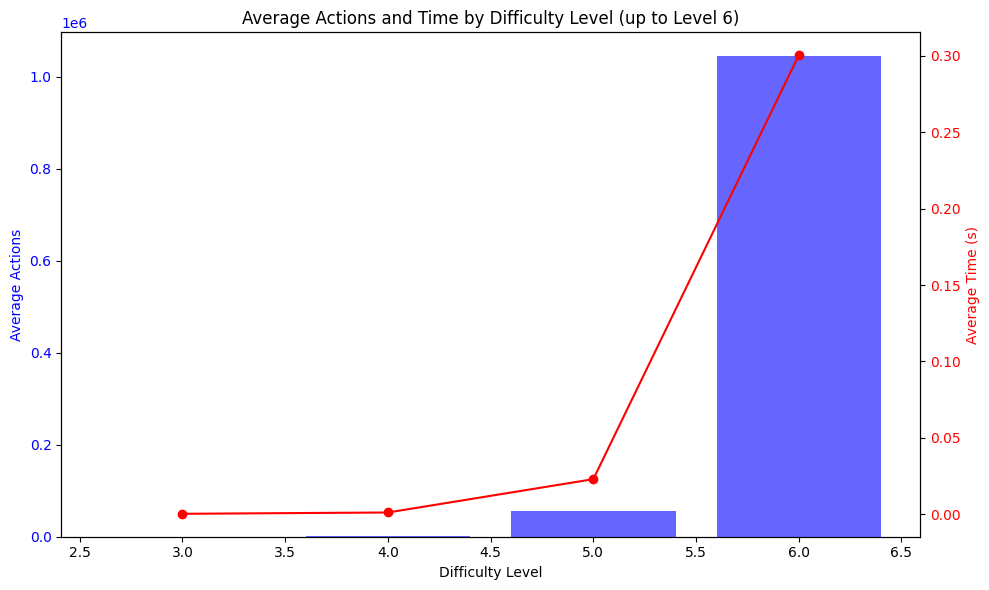

In [24]:
import matplotlib.pyplot as plt

# Calculate average actions and time for each difficulty level up to level 6
average_actions = {level: sum(data["actions"]) / len(data["actions"]) for level, data in level_action_times.items() if level <= 6}
average_time = {level: sum(data["time"]) / len(data["time"]) for level, data in level_action_times.items() if level <= 6}

# Create a bar plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot average actions
ax1.bar(average_actions.keys(), average_actions.values(), color='b', alpha=0.6, label='Average Actions')
ax1.set_xlabel('Difficulty Level')
ax1.set_ylabel('Average Actions', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for average time
ax2 = ax1.twinx()
ax2.plot(average_time.keys(), average_time.values(), color='r', marker='o', label='Average Time')
ax2.set_ylabel('Average Time (s)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title('Average Actions and Time by Difficulty Level (up to Level 6)')
fig.tight_layout()
plt.show()


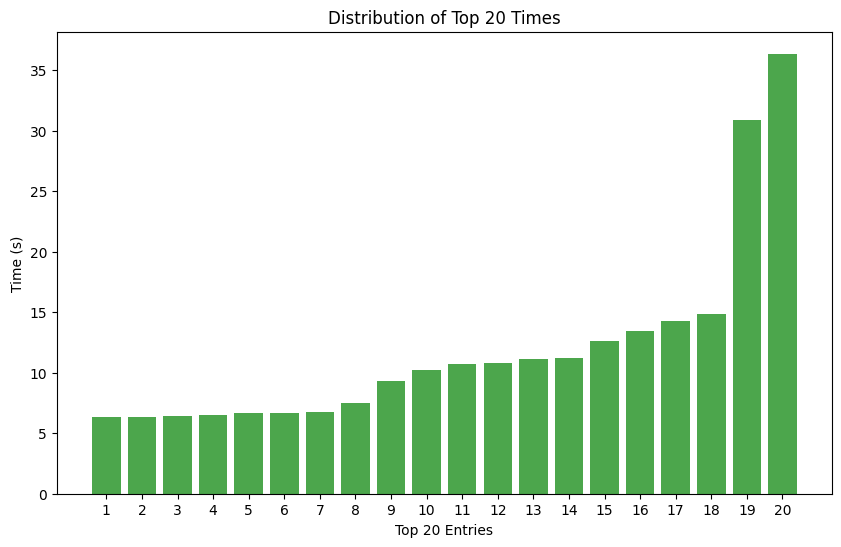

In [21]:
import matplotlib.pyplot as plt

# Flatten all times into a single list
all_times = [time for data in level_action_times.values() for time in data["time"]]

# Sort the times and select the top 20
top_20_times = sorted(all_times)[-20:]

# Plot the distribution of the top 20 times
plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), top_20_times, color='g', alpha=0.7)
plt.xlabel('Top 20 Entries')
plt.ylabel('Time (s)')
plt.title('Distribution of Top 20 Times')
plt.xticks(range(1, 21))
plt.show()


In [23]:
find_expression([22,56,72,35], 113)

(False, 4572)

In [ ]:
# Benchmark: Python DFS vs C++ extension (_merge_search)
from functools import lru_cache
import time

try:
    from custom.verifiers.countdown import _merge_search as _merge_ext
except Exception as e:
    _merge_ext = None
    print("C++ extension not available:", e)

# Python-only: can_merge and action counting (no expression build)
def py_can_merge(values, target, tol=1e-6):
    if not values:
        return False, 0

    def _key(nums: tuple[float, ...]) -> tuple[float, ...]:
        return tuple(sorted(round(x, 8) for x in nums))

    @lru_cache(maxsize=None)
    def dfs(state: tuple[float, ...]):
        if len(state) == 1:
            return abs(state[0] - target) < tol, 0
        n = len(state)
        total_actions = 0
        for i in range(n):
            for j in range(i + 1, n):
                a, b = state[i], state[j]
                rest = [state[k] for k in range(n) if k != i and k != j]
                candidates = [a + b, a * b, a - b, b - a]
                if abs(b) > tol:
                    candidates.append(a / b)
                if abs(a) > tol:
                    candidates.append(b / a)
                for c in candidates:
                    next_state = tuple(rest + [c])
                    can_merge, actions = dfs(_key(next_state))
                    total_actions += actions + 1
                    if can_merge:
                        return True, total_actions
        return False, total_actions

    return dfs(_key(tuple(float(v) for v in values)))


def bench_case(values, target):
    # Python
    t0 = time.perf_counter()
    py_res = py_can_merge(values, float(target))
    t1 = time.perf_counter()
    # C++
    if _merge_ext is not None:
        t2 = time.perf_counter()
        cpp_res = _merge_ext.can_merge_to_target([float(v) for v in values], float(target), 1e-6)
        t3 = time.perf_counter()
    else:
        cpp_res, t2, t3 = (None, None), None, None

    return {
        "values": values,
        "target": target,
        "py": {"res": py_res, "time": t1 - t0},
        "cpp": {"res": cpp_res, "time": (t3 - t2) if t2 is not None else None},
    }


cases = [
    ([1, 2, 3, 4], 24),
    ([3, 3, 8, 8], 24),
    ([5, 5, 5, 1], 24),
    ([9, 9, 9, 9], 24),
    ([56, 70, 23, 71, 53, 56], 201),
    ([15, 70, 23, 53, 56], 201),
    ([15, 47, 53, 56], 201),
    ([15, 47, 53 * 56], 201),
    ([56, 70, 23, 71, 53, 10800], 201),
    ([76, 10, 72, 1, 11, 44, 5], 844),
    ([15, 60, 1, 16, 60, 54, 21, 88], 405),
]

results = []
for vals, tgt in cases:
    results.append(bench_case(vals, tgt))

for r in results:
    print(r["values"], r["target"],
          "PY:", r["py"]["res"], f"{r['py']['time']*1000:.2f} ms",
          "CPP:", r["cpp"]["res"], (f"{r['cpp']['time']*1000:.2f} ms" if r["cpp"]["time"] is not None else None))

# Simple speedup summary where both succeeded
if _merge_ext is not None:
    speedups = []
    for r in results:
        if r["cpp"]["time"] is not None and r["py"]["time"] > 0:
            speedups.append(r["py"]["time"] / r["cpp"]["time"])
    if speedups:
        print(f"Median speedup (PY/CPP): {sorted(speedups)[len(speedups)//2]:.2f}x")



In [1]:
import sys
sys.path.append("/users/stalaei/code/pass_at_k/custom/verifiers/countdown")
from partial_countdown_verifier import _can_merge_to_target_with_timeout

In [2]:
_can_merge_to_target_with_timeout([1, 2, 3, 4,5,6,7,8,9,10], 1000, 1e-6, 0.1)

(True, 546022)